In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows
# plt.rcParams['font.family'] = 'AppleGothic'   # Mac이면 이걸로 교체
plt.rcParams['axes.unicode_minus'] = False       # 마이너스 기호 깨짐 방지

# 데이터 변수 확인

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('hillstrom.csv')

print(df.shape)
print(df.dtypes)

df.describe()

(64000, 12)
recency              int64
history_segment     object
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
segment             object
visit                int64
conversion           int64
spend              float64
dtype: object


,recency,history,mens,womens,newbie,visit,conversion,spend
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000


In [3]:
for col in ['history_segment', 'zip_code','channel','segment']:
    print(f'[{col}]',df[col].unique())

[history_segment] ['2) $100 - $200' '3) $200 - $350' '5) $500 - $750' '1) $0 - $100'
 '6) $750 - $1,000' '4) $350 - $500' '7) $1,000 +']
[zip_code] ['Surburban' 'Rural' 'Urban']
[channel] ['Phone' 'Web' 'Multichannel']
[segment] ['Womens E-Mail' 'No E-Mail' 'Mens E-Mail']


#  결측치 확인

In [4]:
missing = df.isnull().sum()
missing_pct = (missing/len(df) *100).round(2)

pd.DataFrame({'결측 수': missing, '결측 비율(%)':missing_pct})

,결측 수,결측 비율(%)
recency,0,0.0
history_segment,0,0.0
history,0,0.0
mens,0,0.0
womens,0,0.0
zip_code,0,0.0
newbie,0,0.0
channel,0,0.0
segment,0,0.0
visit,0,0.0


In [5]:
import matplotlib.pyplot as plt

if missing.sum() == 0:
    print("결측치 없음 - 모든 변수 완전한 데이터")
else:
    missing_pct.plot(kind='barh', figsize=(8,5), color='steelblue')
    plt.title('결측치 비율(%)')
    plt.xlabel('%')
    plt.tight_layout()
    plt.show

결측치 없음 - 모든 변수 완전한 데이터


# Treatment / Control 비율 확인

In [6]:
print(df['segment'].value_counts())
print(df['segment'].value_counts(normalize=True).round(3))

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64
segment
Womens E-Mail    0.334
Mens E-Mail      0.333
No E-Mail        0.333
Name: proportion, dtype: float64


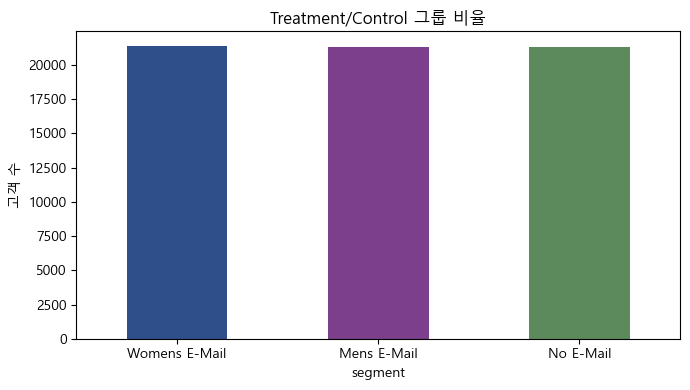

In [7]:
df['segment'].value_counts().plot(kind='bar', figsize=(7,4), color=['#2E4F8A','#7B3F8C','#5C8A5C'])
plt.title('Treatment/Control 그룹 비율')
plt.ylabel('고객 수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
#랜덤 배정 균형 검증 - 그룹별 feature 평균이 비슷한지 확인
df.groupby('segment')[['recency','history','mens','womens','newbie']].mean().round(3)

,recency,history,mens,womens,newbie
segment,,,,,
Mens E-Mail,5.774,242.836,0.551,0.551,0.502
No E-Mail,5.750,240.883,0.553,0.548,0.502
Womens E-Mail,5.768,242.537,0.549,0.550,0.503


# 방문율 / 전환율 / 구매액 분포 확인

In [9]:
segs = ['Mens E-Mail','Womens E-Mail','No E-Mail']

for seg in segs:
    sub = df[df['segment'] == seg]
    print(f'\n[{seg}]')
    print(f'방문율 : {sub["visit"].mean()*100:.2f}%')
    print(f'전환율 : {sub["conversion"].mean()*100:.2f}%')
    print(f'평균 spend: ${sub["spend"].mean():.2f}')


[Mens E-Mail]
방문율 : 18.28%
전환율 : 1.25%
평균 spend: $1.42

[Womens E-Mail]
방문율 : 15.14%
전환율 : 0.88%
평균 spend: $1.08

[No E-Mail]
방문율 : 10.62%
전환율 : 0.57%
평균 spend: $0.65


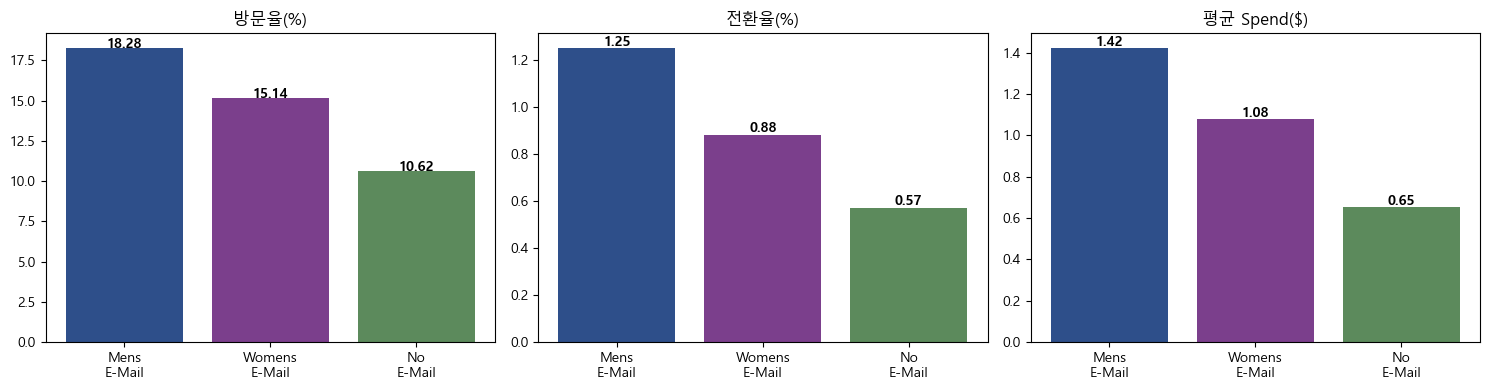

In [10]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
colors = ['#2E4F8A', '#7B3F8C', '#5C8A5C']
labels = ['Mens\nE-Mail','Womens\nE-Mail','No\nE-Mail']

metrics = {
    '방문율(%)': [df[df['segment']==s]['visit'].mean()*100 for s in segs],
    '전환율(%)': [df[df['segment']==s]['conversion'].mean()*100 for s in segs],
    '평균 Spend($)': [df[df['segment']==s]['spend'].mean() for s in segs],
}
for ax, (title, vals) in zip(axes, metrics.items()):
    bars = ax.bar(labels, vals, color=colors)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() +0.01,
                f'{v:.2f}',ha='center',fontweight='bold')
    ax.set_title(title)

plt.tight_layout()
plt.show()

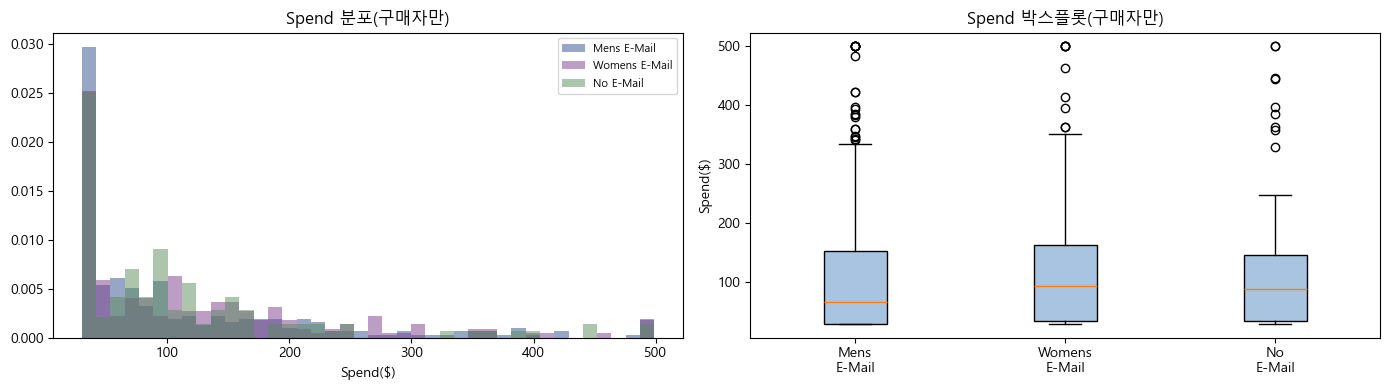

In [11]:
fig, axes = plt.subplots(1,2,figsize=(14,4))

for seg, col in zip(segs, colors):
    data = df[(df['segment']==seg)&(df['spend']>0)]['spend']
    axes[0].hist(data, bins=40, alpha=0.5, color=col, label=seg, density=True)

axes[0].set_title('Spend 분포(구매자만)')
axes[0].set_xlabel('Spend($)')
axes[0].legend(fontsize=8)

data_box = [df[(df['segment']==s)&(df['spend']>0)]['spend'].values for s in segs]
axes[1].boxplot(data_box, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='#A8C4E0'))
axes[1].set_title('Spend 박스플롯(구매자만)')
axes[1].set_ylabel('Spend($)')

plt.tight_layout()
plt.show()

# 주요 Feature와 Outcome의 관계 확인

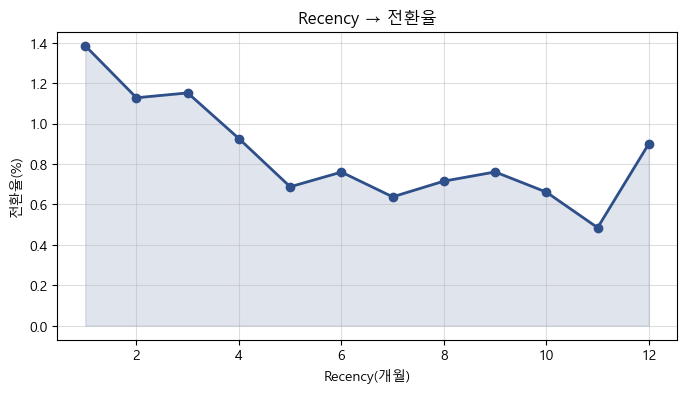

In [12]:
rec_conv = df.groupby('recency')['conversion'].mean()*100

plt.figure(figsize=(8,4))
plt.plot(rec_conv.index, rec_conv.values, 'o-',color='#2E4F8A', linewidth=2)
plt.fill_between(rec_conv.index, rec_conv.values, alpha=0.15, color='#2E4F8A')
plt.title('Recency → 전환율')
plt.xlabel('Recency(개월)')
plt.ylabel('전환율(%)')
plt.grid(alpha=0.4)
plt.show()

['1) $0 - $100', '2) $100 - $200', '3) $200 - $350', '4) $350 - $500', '5) $500 - $750', '6) $750 - $1,000', '7) $1,000 +']


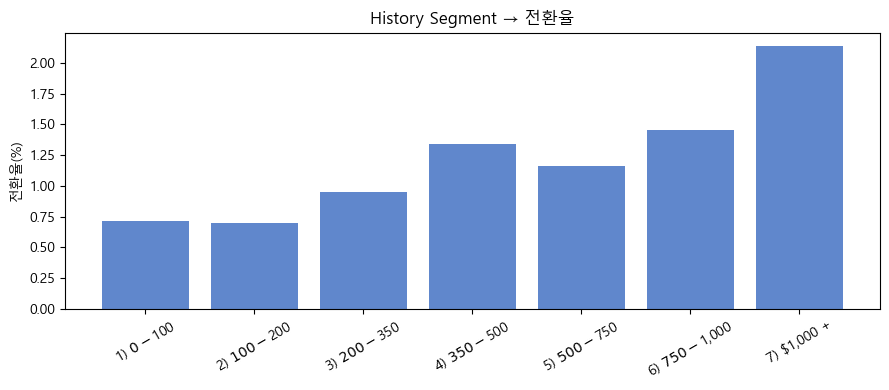

In [13]:
#history_segment → 전환율
hs_order = sorted(df['history_segment'].unique())
print(hs_order)

hs_conv = [df[df['history_segment']==h]['conversion'].mean()*100 for h in hs_order]

plt.figure(figsize=(9,4))
plt.bar(range(len(hs_order)),hs_conv, color='#4472C4', alpha=0.85)
plt.xticks(range(len(hs_order)), hs_order, rotation=30)
plt.title('History Segment → 전환율')
plt.ylabel('전환율(%)')
plt.tight_layout()
plt.show()

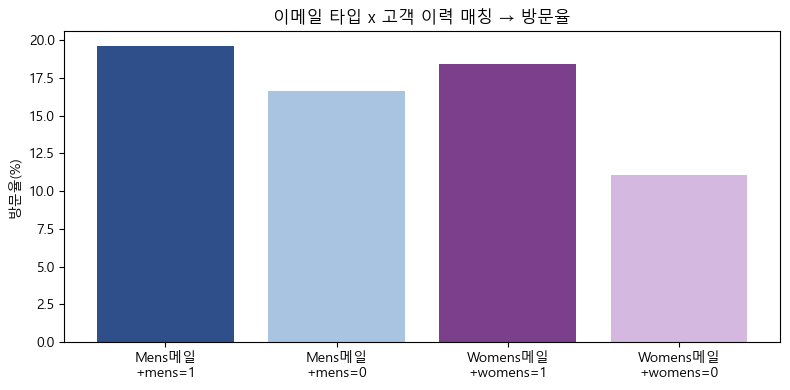

In [14]:
# mens/womens 이메일 매칭 효과
combos = {
    'Mens메일\n+mens=1':     df[(df['segment']=='Mens E-Mail')   & (df['mens']==1)]['visit'].mean()*100,
    'Mens메일\n+mens=0':     df[(df['segment']=='Mens E-Mail')   & (df['mens']==0)]['visit'].mean()*100,
    'Womens메일\n+womens=1': df[(df['segment']=='Womens E-Mail') & (df['womens']==1)]['visit'].mean()*100,
    'Womens메일\n+womens=0': df[(df['segment']=='Womens E-Mail') & (df['womens']==0)]['visit'].mean()*100,
}

plt.figure(figsize=(8,4))
plt.bar(combos.keys(), combos.values(),color=['#2E4F8A','#A8C4E0','#7B3F8C','#D4B8E0'])
plt.title('이메일 타입 x 고객 이력 매칭 → 방문율')
plt.ylabel('방문율(%)')
plt.tight_layout()
plt.show()

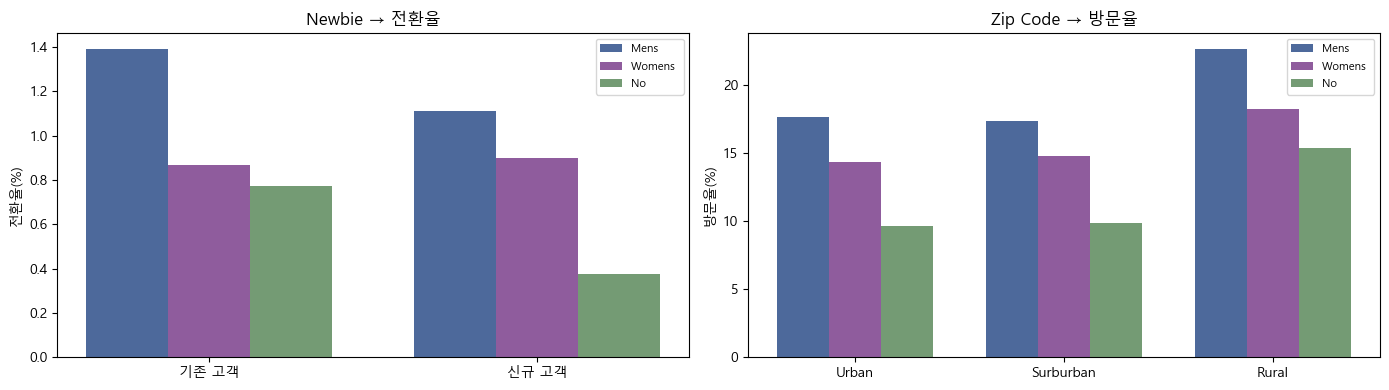

In [15]:
#newbie / zip_code -> 전환율
fig, axes = plt.subplots(1,2,figsize=(14,4))

#newbie
x = np.arange(2)
for i , (seg, col) in enumerate(zip(segs, colors)):
    rates = [df[(df['segment']==seg) & (df['newbie']==n)]['conversion'].mean()*100 for n in [0,1]]
    axes[0].bar(x+i*0.25, rates, width=0.25, color=col, alpha=0.85, label=seg.replace('E-Mail',''))
axes[0].set_xticks(x+0.25)
axes[0].set_xticklabels(['기존 고객','신규 고객'])
axes[0].set_title('Newbie → 전환율')
axes[0].set_ylabel('전환율(%)')
axes[0].legend(fontsize=8)

#zip_code
zips = ['Urban','Surburban','Rural']
x2 = np.arange(3)
for i, (seg, col) in enumerate(zip(segs, colors)):
    rates = [df[(df['segment']==seg) & (df['zip_code']==z)]['visit'].mean()*100 for z in zips]
    axes[1].bar(x2 + i*0.25, rates, width=0.25, color=col, alpha=0.85, label=seg.replace('E-Mail',''))
axes[1].set_xticks(x2 + 0.25)
axes[1].set_xticklabels(zips)
axes[1].set_title('Zip Code → 방문율')
axes[1].set_ylabel('방문율(%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# 학습 Feature 정리(모델에 넣을 변수 정리)

In [16]:
df_model = df.copy()

#zip_code 오타 수정
df_model['zip_code'] = df_model['zip_code'].replace('Surburban', 'Suburban')

hs_order = {
    '1) $0 - $100'    : 1,
    '2) $100 - $200'  : 2,
    '3) $200 - $350'  : 3,
    '4) $350 - $500'  : 4,
    '5) $500 - $750'  : 5,
    '6) $750 - $1,000': 6,
    '7) $1,000 +'     : 7,
}
df_model['history_segment_enc']=df_model['history_segment'].map(hs_order)

df_model = pd.get_dummies(df_model, columns=['zip_code','channel'], drop_first=False)

print(df_model.columns.tolist())
print(df_model.shape)

['recency', 'history_segment', 'history', 'mens', 'womens', 'newbie', 'segment', 'visit', 'conversion', 'spend', 'history_segment_enc', 'zip_code_Rural', 'zip_code_Suburban', 'zip_code_Urban', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
(64000, 17)


In [17]:
#최종 학습에 사용할 feature 목록
FEATURES = [
     'recency',              # ★★★ 핵심
    'history',              # ★★☆
    'history_segment_enc',  # ★★☆ (history 보완)
    'mens',                 # ★★★
    'womens',               # ★★★
    'newbie',               # ★★☆
    'zip_code_Urban',       # ★☆☆
    'zip_code_Suburban',    # ★☆☆
    'zip_code_Rural',       # ★☆☆
    'channel_Phone',        # ★☆☆
    'channel_Web',          # ★☆☆
    'channel_Multichannel', # ★☆☆
]

TARGET = 'conversion'#메인 타겟

print(f'학습 feature 수: {len(FEATURES)}개')
print(f'타겟 변수: {TARGET}')
df_model[FEATURES].describe()

학습 feature 수: 12개
타겟 변수: conversion


,recency,history,history_segment_enc,mens,womens,newbie
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,2.481969,0.551031,0.549719,0.502250
std,3.507592,256.158608,1.544514,0.497393,0.497526,0.499999
min,1.000000,29.990000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,1.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,2.000000,1.000000,1.000000,1.000000
75%,9.000000,325.657500,3.000000,1.000000,1.000000,1.000000
max,12.000000,3345.930000,7.000000,1.000000,1.000000,1.000000


In [18]:
#feature 최종 정리표 출력
feature_summary = pd.DataFrame({
    'feature': FEATURES,
    'type': [
        'int', 'float', 'int(ordinal)',
        'binary', 'binary', 'binary',
        'dummy', 'dummy', 'dummy',
        'dummy', 'dummy', 'dummy'
    ],
    '중요도': [
        '★★★', '★★☆', '★★☆',
        '★★★', '★★★', '★★☆',
        '★☆☆', '★☆☆', '★☆☆',
        '★☆☆', '★☆☆', '★☆☆'
    ],
    '근거': [
        '최근 구매자 전환율 3배',
        '고액 구매 이력 → 재전환 높음',
        'EDA에서 우상향 패턴 확인',
        '이메일 매칭 효과 확인',
        '이메일 매칭 효과 확인',
        '기존 고객 전환율 일관되게 높음',
        'Rural 방문율 높으나 uplift 영향 낮음',
        'Rural 방문율 높으나 uplift 영향 낮음',
        'Rural 방문율 높으나 uplift 영향 낮음',
        '그룹 간 차이 미미',
        '그룹 간 차이 미미',
        '그룹 간 차이 미미',
    ]
})

print(feature_summary.to_string(index=False))

             feature         type 중요도                         근거
             recency          int ★★★              최근 구매자 전환율 3배
             history        float ★★☆          고액 구매 이력 → 재전환 높음
 history_segment_enc int(ordinal) ★★☆            EDA에서 우상향 패턴 확인
                mens       binary ★★★               이메일 매칭 효과 확인
              womens       binary ★★★               이메일 매칭 효과 확인
              newbie       binary ★★☆          기존 고객 전환율 일관되게 높음
      zip_code_Urban        dummy ★☆☆ Rural 방문율 높으나 uplift 영향 낮음
   zip_code_Suburban        dummy ★☆☆ Rural 방문율 높으나 uplift 영향 낮음
      zip_code_Rural        dummy ★☆☆ Rural 방문율 높으나 uplift 영향 낮음
       channel_Phone        dummy ★☆☆                 그룹 간 차이 미미
         channel_Web        dummy ★☆☆                 그룹 간 차이 미미
channel_Multichannel        dummy ★☆☆                 그룹 간 차이 미미


In [19]:
# Response Model용 → segment를 binary로
df_model['treatment_mens']   = (df_model['segment'] == 'Mens E-Mail').astype(int)
df_model['treatment_womens'] = (df_model['segment'] == 'Womens E-Mail').astype(int)
df_model['treatment']        = (df_model['segment'] != 'No E-Mail').astype(int)

# Uplift Model용 → treatment 0/1
# Mens만 분석할 경우
df_mens = df_model[df_model['segment'].isin(['Mens E-Mail', 'No E-Mail'])].copy()
df_mens['treatment'] = (df_mens['segment'] == 'Mens E-Mail').astype(int)

# Womens만 분석할 경우
df_womens = df_model[df_model['segment'].isin(['Womens E-Mail', 'No E-Mail'])].copy()
df_womens['treatment'] = (df_womens['segment'] == 'Womens E-Mail').astype(int)

print('Mens 데이터:', df_mens.shape)
print('Womens 데이터:', df_womens.shape)
print('\nTreatment 비율 (Mens):')
print(df_mens['treatment'].value_counts())

Mens 데이터: (42613, 20)
Womens 데이터: (42693, 20)

Treatment 비율 (Mens):
treatment
1    21307
0    21306
Name: count, dtype: int64


# 모델링

In [20]:
#공통 준비
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

#Mens 기준 진행(Womens도 동일 구조)
df_mens = df_model[df_model['segment'].isin(['Mens E-Mail','No E-Mail'])].copy()
df_mens['treatment'] = (df_mens['segment']=='Mens E-Mail').astype(int)

FEATURES = [
    'recency', 'history', 'history_segment_enc',
    'mens', 'womens', 'newbie',
    'zip_code_Urban', 'zip_code_Suburban', 'zip_code_Rural',
    'channel_Phone', 'channel_Web', 'channel_Multichannel'
]
TARGET = 'conversion'

X = df_mens[FEATURES]
Y = df_mens[TARGET]
T = df_mens['treatment']

X_train, X_test, y_train, y_test, T_train,T_test = train_test_split(
    X,Y,T,test_size=0.2, random_state=42, stratify=Y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'전환율(train):{y_train.mean()*100:.2f}%')

Train: (34090, 12), Test: (8523, 12)
전환율(train):0.91%


In [21]:
#Baseline - 전체 발송 : 모든 고객에게 이메일 발송 / 아무 모델 없이 무조건 send -> 전환율 = treatment 그룹 전환율

baseline_conversion = df_mens[df_mens['treatment']==1][TARGET].mean()
baseline_spend = df_mens[df_mens['treatment']==1]['spend'].mean()
ctrl_conversion = df_mens[df_mens['treatment']==0][TARGET].mean()

print('===Baseline(전체 발송)===')
print(f'이메일 발송 그룹 전환율 : {baseline_conversion*100:.2f}%')
print(f'Control 그룹 전환율: {ctrl_conversion*100:.2f}%')
print(f'Raw Uplift: +{(baseline_conversion - ctrl_conversion)*100:.2f}%p')

===Baseline(전체 발송)===
이메일 발송 그룹 전환율 : 1.25%
Control 그룹 전환율: 0.57%
Raw Uplift: +0.68%p


In [22]:
# Response Model - Logistic Regression
#response Model : 구매확률 높은 고객 타겟 & treatment/control 구분 없이 전체로 학습

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter = 1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict_proba(X_test_sc)[:,1]

print('===Response Model: Logistic Regression===')
print(f'AUC:{roc_auc_score(y_test, y_pred_lr):.4f}')

===Response Model: Logistic Regression===
AUC:0.6621


In [23]:
# Response Model - Random Forest

from sklearn.utils import resample

df_train_bal = X_train.copy()
df_train_bal['conversion'] = y_train.values

majority = df_train_bal[df_train_bal['conversion']==0]
minority = df_train_bal[df_train_bal['conversion']==1]

majority_down = resample(majority,
                         n_samples=len(minority)*10, #10:1비율
                         random_state=42)

df_balanced = pd.concat([majority_down, minority])
X_train_bal = df_balanced[FEATURES]
y_train_bal = df_balanced['conversion']

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_bal, y_train_bal)

y_pred_rf = rf.predict_proba(X_test)[:,1]

print('===Response Model: Random Forest===')
print(f'AUC: {roc_auc_score(y_test, y_pred_rf):.4f}')

fi=pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print('\nFeature Importance:')
print(fi.round(4))

===Response Model: Random Forest===
AUC: 0.5225

Feature Importance:
history                 0.4405
recency                 0.2517
history_segment_enc     0.0768
newbie                  0.0413
womens                  0.0303
mens                    0.0300
zip_code_Suburban       0.0254
channel_Web             0.0248
zip_code_Urban          0.0240
channel_Phone           0.0219
zip_code_Rural          0.0209
channel_Multichannel    0.0123
dtype: float64


In [24]:
#uplift Model - S-Learner : treatment를 feature로 포함해 하나의 모델로 학습
FEATURES_S = FEATURES + ['treatment']

X_s_train = X_train.copy(); X_s_train['treatment'] = T_train.values
X_s_test  = X_test.copy();  X_s_test['treatment']  = T_test.values

rf_s = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                               random_state=42, n_jobs=-1)
rf_s.fit(X_s_train, y_train)

# Uplift = P(Y=1|X, T=1) - P(Y=1|X, T=0)
X_test_t1 = X_test.copy(); X_test_t1['treatment'] = 1
X_test_t0 = X_test.copy(); X_test_t0['treatment'] = 0

uplift_s = (rf_s.predict_proba(X_test_t1)[:, 1] -
            rf_s.predict_proba(X_test_t0)[:, 1])

print('=== Uplift Model: S-Learner ===')
print(f'평균 Uplift Score: {uplift_s.mean():.4f}')
print(f'Uplift > 0 비율:   {(uplift_s > 0).mean()*100:.1f}%')

=== Uplift Model: S-Learner ===
평균 Uplift Score: 0.0060
Uplift > 0 비율:   17.0%


In [25]:
#uplift Model - T-learner : treatment/control 각각 별도 모델로 학습
# Treatment 그룹 모델
rf_t1 = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_t1.fit(X_train[T_train == 1], y_train[T_train == 1])

# Control 그룹 모델
rf_t0 = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_t0.fit(X_train[T_train == 0], y_train[T_train == 0])

# Uplift = P(Y=1|X, T=1) - P(Y=1|X, T=0)
uplift_t = (rf_t1.predict_proba(X_test)[:, 1] -
            rf_t0.predict_proba(X_test)[:, 1])

print('=== Uplift Model: T-Learner ===')
print(f'평균 Uplift Score: {uplift_t.mean():.4f}')
print(f'Uplift > 0 비율:   {(uplift_t > 0).mean()*100:.1f}%')

=== Uplift Model: T-Learner ===
평균 Uplift Score: 0.0052
Uplift > 0 비율:   21.2%


In [26]:
#uplift MOdel - X-Learner : T-Learner 결과로 imputed tratment effect 재학습
# Step 1: T-Learner로 각 그룹 예측값 구하기 (위에서 이미 학습됨)
# Step 2: Imputed treatment effect 계산
tau_t1 = y_train[T_train==1].values - rf_t0.predict_proba(X_train[T_train==1])[:,1]
tau_t0 = rf_t1.predict_proba(X_train[T_train==0])[:,1] - y_train[T_train==0].values

# Step 3: 각 그룹에 대해 CATE 모델 학습
from sklearn.ensemble import GradientBoostingRegressor

x_model_t1 = GradientBoostingRegressor(n_estimators=100, random_state=42)
x_model_t0 = GradientBoostingRegressor(n_estimators=100, random_state=42)

x_model_t1.fit(X_train[T_train==1], tau_t1)
x_model_t0.fit(X_train[T_train==0], tau_t0)

# Step 4: Uplift = 가중 평균 (propensity score로 가중)
p = T_train.mean()  # 단순 propensity
uplift_x = (p * x_model_t0.predict(X_test) +
            (1-p) * x_model_t1.predict(X_test))

print('=== Uplift Model: X-Learner ===')
print(f'평균 Uplift Score: {uplift_x.mean():.4f}')
print(f'Uplift > 0 비율:   {(uplift_x > 0).mean()*100:.1f}%')


=== Uplift Model: X-Learner ===
평균 Uplift Score: 0.0060
Uplift > 0 비율:   86.1%


In [27]:
#최종 결과표 출력

result_df = X_test.copy().reset_index(drop=True)
result_df['customer_id']     = result_df.index + 1001
result_df['uplift_score']    = uplift_x.round(3)   # X-Learner 기준
result_df['conversion_prob'] = y_pred_rf            # Response Model 확률

# Segment 분류 (Uplift 기반)
def classify_segment(uplift):
    if uplift > 0.01:   return 'Persuadable'    # 이메일 받으면 행동 바뀜
    elif uplift > 0:    return 'Sure Thing'      # 원래 살 사람
    else:               return 'Sleeping Dog'    # 이메일 역효과

result_df['segment']        = result_df['uplift_score'].apply(classify_segment)
result_df['recommendation'] = result_df['uplift_score'].apply(
    lambda x: 'Send' if x > 0.01 else 'Do not send'
)

# Top 3 feature (RF feature importance 순서 고정)
top3 = fi.index[:3].tolist()
result_df['top_factor_1'] = top3[0]
result_df['top_factor_2'] = top3[1]
result_df['top_factor_3'] = top3[2]

# 출력
final_cols = ['customer_id','uplift_score','segment','recommendation',
              'top_factor_1','top_factor_2','top_factor_3']
print(result_df[final_cols].head(10).to_string(index=False))

 customer_id  uplift_score     segment recommendation top_factor_1 top_factor_2        top_factor_3
        1001         0.017 Persuadable           Send      history      recency history_segment_enc
        1002         0.005  Sure Thing    Do not send      history      recency history_segment_enc
        1003         0.013 Persuadable           Send      history      recency history_segment_enc
        1004         0.003  Sure Thing    Do not send      history      recency history_segment_enc
        1005         0.009  Sure Thing    Do not send      history      recency history_segment_enc
        1006         0.005  Sure Thing    Do not send      history      recency history_segment_enc
        1007         0.008  Sure Thing    Do not send      history      recency history_segment_enc
        1008         0.026 Persuadable           Send      history      recency history_segment_enc
        1009         0.003  Sure Thing    Do not send      history      recency history_segment_enc


In [28]:
print(result_df['segment'].value_counts())
print(result_df['recommendation'].value_counts())

segment
Sure Thing      5179
Persuadable     2028
Sleeping Dog    1316
Name: count, dtype: int64
recommendation
Do not send    6495
Send           2028
Name: count, dtype: int64


# 평가 기준 정리

In [29]:
# ── 공통 준비 ──
# uplift 점수 기준으로 정렬된 테스트 데이터 준비
eval_df = X_test.copy().reset_index(drop=True)
eval_df['uplift_score']  = uplift_t          # T-Learner 기준
eval_df['conversion']    = y_test.values
eval_df['treatment']     = T_test.values
eval_df = eval_df.sort_values('uplift_score', ascending=False).reset_index(drop=True)

In [30]:
# ── Uplift @ 10% / 20% / 30% ──
def uplift_at_k(df, k):
    n = int(len(df) * k)
    top_k = df.iloc[:n]
    
    treat = top_k[top_k['treatment'] == 1]['conversion'].mean()
    ctrl  = top_k[top_k['treatment'] == 0]['conversion'].mean()
    
    return (treat - ctrl) * 100

u10 = uplift_at_k(eval_df, 0.10)
u20 = uplift_at_k(eval_df, 0.20)
u30 = uplift_at_k(eval_df, 0.30)

print('=== Uplift @ K ===')
print(f'Uplift @ 10%: {u10:.4f}%p')
print(f'Uplift @ 20%: {u20:.4f}%p')
print(f'Uplift @ 30%: {u30:.4f}%p')
print(f'Baseline    : {(eval_df[eval_df["treatment"]==1]["conversion"].mean() - eval_df[eval_df["treatment"]==0]["conversion"].mean())*100:.4f}%p')

=== Uplift @ K ===
Uplift @ 10%: 0.7908%p
Uplift @ 20%: 1.0827%p
Uplift @ 30%: 0.6436%p
Baseline    : 0.8321%p


In [31]:
# ── Qini Curve + AUUC ──
import matplotlib.pyplot as plt
import numpy as np

def qini_curve(df, uplift_col='uplift_score'):
    df_sorted = df.sort_values(uplift_col, ascending=False).reset_index(drop=True)
    
    n = len(df_sorted)
    n_treat = df_sorted['treatment'].sum()
    n_ctrl  = n - n_treat
    
    qini_vals = [0]
    random_vals = [0]
    
    cum_treat_conv = 0
    cum_ctrl_conv  = 0
    cum_treat      = 0
    cum_ctrl       = 0
    
    for i, row in df_sorted.iterrows():
        if row['treatment'] == 1:
            cum_treat += 1
            cum_treat_conv += row['conversion']
        else:
            cum_ctrl += 1
            cum_ctrl_conv += row['conversion']
        
        if cum_treat > 0 and cum_ctrl > 0:
            qini = cum_treat_conv - cum_ctrl_conv * (cum_treat / cum_ctrl)
        else:
            qini = 0
        qini_vals.append(qini)
        random_vals.append(i * (qini_vals[-1]) / n if i > 0 else 0)
    
    return qini_vals

# 모델별 Qini Curve 계산
eval_s = eval_df.copy(); eval_s['uplift_score'] = uplift_s
eval_t = eval_df.copy(); eval_t['uplift_score'] = uplift_t
eval_x = eval_df.copy(); eval_x['uplift_score'] = uplift_x

qini_s = qini_curve(eval_s)
qini_t = qini_curve(eval_t)
qini_x = qini_curve(eval_x)

x_axis = np.linspace(0, 1, len(qini_t))

# AUUC 계산
auuc_s = np.trapz(qini_s) / len(qini_s)
auuc_t = np.trapz(qini_t) / len(qini_t)
auuc_x = np.trapz(qini_x) / len(qini_x)

print('=== AUUC ===')
print(f'S-Learner AUUC: {auuc_s:.4f}')
print(f'T-Learner AUUC: {auuc_t:.4f}')
print(f'X-Learner AUUC: {auuc_x:.4f}')

=== AUUC ===
S-Learner AUUC: 16.1428
T-Learner AUUC: 17.2452
X-Learner AUUC: 19.1303


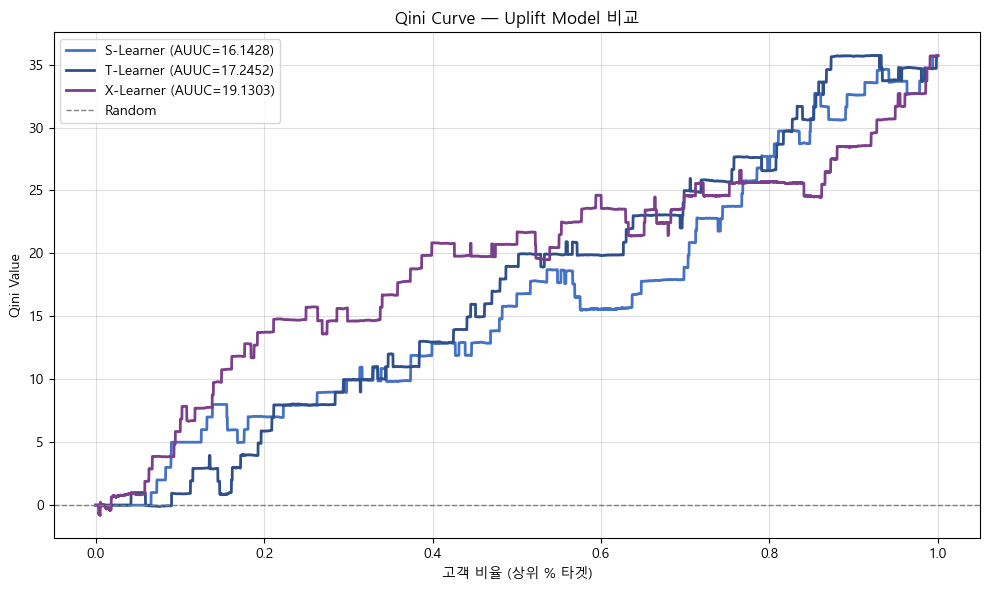

In [32]:
# ── Qini Curve 시각화 ──
plt.figure(figsize=(10, 6))
plt.plot(x_axis, qini_s[:len(x_axis)], label=f'S-Learner (AUUC={auuc_s:.4f})', color='#4472C4', linewidth=2)
plt.plot(x_axis, qini_t[:len(x_axis)], label=f'T-Learner (AUUC={auuc_t:.4f})', color='#2E4F8A', linewidth=2)
plt.plot(x_axis, qini_x[:len(x_axis)], label=f'X-Learner (AUUC={auuc_x:.4f})', color='#7B3F8C', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=1, label='Random')
plt.title('Qini Curve — Uplift Model 비교')
plt.xlabel('고객 비율 (상위 % 타겟)')
plt.ylabel('Qini Value')
plt.legend(fontsize=10)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [33]:
# ── 전체 평가 결과 최종 정리 ──
print('=' * 50)
print('📋 모델 평가 최종 결과')
print('=' * 50)
print(f'\n[Response Model]')
print(f'  Logistic Regression AUC : 0.6621  ✅ 채택')
print(f'  Random Forest AUC       : 0.5225')

print(f'\n[Uplift @ K]')
print(f'  Uplift @ 10% : {u10:.4f}%p')
print(f'  Uplift @ 20% : {u20:.4f}%p')
print(f'  Uplift @ 30% : {u30:.4f}%p')
print(f'  Baseline     : {(eval_df[eval_df["treatment"]==1]["conversion"].mean() - eval_df[eval_df["treatment"]==0]["conversion"].mean())*100:.4f}%p')

print(f'\n[AUUC]')
print(f'  S-Learner : {auuc_s:.4f}')
print(f'  T-Learner : {auuc_t:.4f}')
print(f'  X-Learner : {auuc_x:.4f}')

📋 모델 평가 최종 결과

[Response Model]
  Logistic Regression AUC : 0.6621  ✅ 채택
  Random Forest AUC       : 0.5225

[Uplift @ K]
  Uplift @ 10% : 0.7908%p
  Uplift @ 20% : 1.0827%p
  Uplift @ 30% : 0.6436%p
  Baseline     : 0.8321%p

[AUUC]
  S-Learner : 16.1428
  T-Learner : 17.2452
  X-Learner : 19.1303


# 전체 64,000명 T-Learner 예측 -> CSV 저장 코드

In [34]:
# ── Womens용 T-Learner 학습 ──
df_womens_full = df_model[df_model['segment'].isin(['Womens E-Mail', 'No E-Mail'])].copy()
df_womens_full['treatment'] = (df_womens_full['segment'] == 'Womens E-Mail').astype(int)

X_w = df_womens_full[FEATURES]
y_w = df_womens_full['conversion']
T_w = df_womens_full['treatment']

X_train_w, X_test_w, y_train_w, y_test_w, T_train_w, T_test_w = train_test_split(
    X_w, y_w, T_w, test_size=0.2, random_state=42, stratify=y_w
)

# Womens Treatment 모델
rf_t1_w = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_t1_w.fit(X_train_w[T_train_w == 1], y_train_w[T_train_w == 1])

# Womens Control 모델
rf_t0_w = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_t0_w.fit(X_train_w[T_train_w == 0], y_train_w[T_train_w == 0])

print('✅ Womens T-Learner 학습 완료')

✅ Womens T-Learner 학습 완료


In [35]:
# ── 전체 64,000명 uplift 예측 ──
X_full = df_model[FEATURES]

# Mens T-Learner 예측 (기존 rf_t1, rf_t0)
uplift_mens = (rf_t1.predict_proba(X_full)[:, 1] -
               rf_t0.predict_proba(X_full)[:, 1])

# Womens T-Learner 예측
uplift_womens = (rf_t1_w.predict_proba(X_full)[:, 1] -
                 rf_t0_w.predict_proba(X_full)[:, 1])

# segment별로 적합한 uplift 사용
def get_uplift(row_idx):
    seg = df_model['segment'].iloc[row_idx]
    if seg == 'Mens E-Mail':
        return uplift_mens[row_idx]
    elif seg == 'Womens E-Mail':
        return uplift_womens[row_idx]
    else:  # No E-Mail → 두 모델 평균
        return (uplift_mens[row_idx] + uplift_womens[row_idx]) / 2

uplift_final = [get_uplift(i) for i in range(len(df_model))]
print('✅ 전체 uplift 예측 완료')

✅ 전체 uplift 예측 완료


In [36]:
# ── CSV 저장 ──
result_full = pd.DataFrame()
result_full['customer_id']  = range(1001, 1001 + len(df_model))
result_full['uplift_score'] = [round(u, 3) for u in uplift_final]
result_full['spend']        = df_model['spend'].values
result_full['treatment']    = (df_model['segment'] != 'No E-Mail').astype(int).values
result_full['segment']      = df_model['segment'].values  # 어떤 이메일 받았는지 참고용

print(f'전체 데이터 크기: {result_full.shape}')
print(result_full.head(10).to_string(index=False))
print(f'\nuplift_score 기술통계:')
print(result_full['uplift_score'].describe().round(4))
print(f'\nsegment별 평균 uplift:')
print(result_full.groupby('segment')['uplift_score'].mean().round(4))

전체 데이터 크기: (64000, 5)
 customer_id  uplift_score  spend  treatment       segment
        1001         0.000    0.0          1 Womens E-Mail
        1002        -0.005    0.0          0     No E-Mail
        1003         0.000    0.0          1 Womens E-Mail
        1004         0.000    0.0          1   Mens E-Mail
        1005         0.000    0.0          1 Womens E-Mail
        1006         0.000    0.0          1 Womens E-Mail
        1007         0.000    0.0          1 Womens E-Mail
        1008         0.000    0.0          1 Womens E-Mail
        1009         0.037    0.0          1   Mens E-Mail
        1010         0.000    0.0          1 Womens E-Mail

uplift_score 기술통계:
count    64000.0000
mean         0.0048
std          0.0936
min         -0.7430
25%          0.0000
50%          0.0000
75%          0.0000
max          0.8610
Name: uplift_score, dtype: float64

segment별 평균 uplift:
segment
Mens E-Mail      0.0074
No E-Mail        0.0034
Womens E-Mail    0.0035
Name: uplift_

In [37]:
result_full.to_csv('uplift_prediction_full.csv', index=False)
print('✅ 저장 완료: uplift_prediction_full.csv')
print(f'총 {len(result_full):,}명 저장됨')

✅ 저장 완료: uplift_prediction_full.csv
총 64,000명 저장됨


# 수정 csv

In [40]:
# ── recommendation 컬럼 추가 ──
result_full['recommendation'] = result_full['uplift_score'].apply(
    lambda x: 'Send' if x > 0.01 else 'Do not send'
)

# ── top_factor 공백으로 채우기 (SHAP은 최종발표 때) ──
result_full['top_factor_1'] = ''
result_full['top_factor_2'] = ''
result_full['top_factor_3'] = ''

# ── 컬럼 순서 정리 ──
final_cols = [
    'customer_id',
    'uplift_score',
    'segment',
    'recommendation',
    'top_factor_1',
    'top_factor_2',
    'top_factor_3',
    'spend',
    'treatment',
]
result_full = result_full[final_cols]

# ── 확인 ──
print(result_full.head(10).to_string(index=False))
print(f'\nrecommendation 분포:')
print(result_full['recommendation'].value_counts())

 customer_id  uplift_score       segment recommendation top_factor_1 top_factor_2 top_factor_3  spend  treatment
        1001         0.000 Womens E-Mail    Do not send                                           0.0          1
        1002        -0.005     No E-Mail    Do not send                                           0.0          0
        1003         0.000 Womens E-Mail    Do not send                                           0.0          1
        1004         0.000   Mens E-Mail    Do not send                                           0.0          1
        1005         0.000 Womens E-Mail    Do not send                                           0.0          1
        1006         0.000 Womens E-Mail    Do not send                                           0.0          1
        1007         0.000 Womens E-Mail    Do not send                                           0.0          1
        1008         0.000 Womens E-Mail    Do not send                                         

In [41]:
# ── CSV 저장 ──
result_full.to_csv('uplift_prediction_full_v2.csv', index=False)
print('✅ 저장 완료: uplift_prediction_full_v2.csv')

✅ 저장 완료: uplift_prediction_full_v2.csv
